# Tiempo de ejecución

In [1]:
import os
import re

directory = os.fsencode("../logs")

dict_cpu_time = dict()
dict_gpu_time = dict()
dict_mgpu_time = dict()
dict_all_time = dict()

time_pattern_cpu_gpu = re.compile(r"^Entrenamiento completado en (\d+\.\d+)s$")
time_pattern_mgpu = re.compile(r"^Tiempo total: (\d+\.\d+)s$")

filename_patterns = ["grad_acc", "ipex", "batch16", "batch32", "fp16", "fp32"]

for file in os.listdir(directory):
    filename = os.fsdecode(file)
    if filename.endswith(".out"):
        for line in open(os.path.join(os.fsdecode(directory),filename)):
            if filename.find("_mgpu_") != -1:
                matches = re.findall(time_pattern_mgpu, line)
            else:
                matches = re.findall(time_pattern_cpu_gpu, line)

            if len(matches) != 1:
                continue
            
            match = matches[0]

            seconds = float(match)

            print(f"{filename}: {seconds} seconds.")

            string_list = []

            if filename.find("_cpu_") != -1:
                string_list.append("CPU")
            elif filename.find("_gpu_") != -1:
                string_list.append("GPU")
            elif filename.find("_mgpu_") != -1:
                string_list.append("Multi-GPU")
            else:
                print(f"ERROR: no se encontraron las subcadenas _cpu_, _gpu_ o _mgpu_ en el nombre del fichero {filename}")
                exit()

            for pattern in filename_patterns:
                if filename.find("_"+pattern+"_") != -1:
                    string_list.append(pattern)
            
            if filename.find("_cpu_") != -1:
                dict_cpu_time[" ".join(string_list)] = seconds
            elif filename.find("_gpu_") != -1:
                dict_gpu_time[" ".join(string_list)] = seconds
            elif filename.find("_mgpu_") != -1:
                dict_mgpu_time[" ".join(string_list)] = seconds

            dict_all_time[" ".join(string_list)] = seconds

distilbert_job_train_cpu_batch16_2904.out: 107.75 seconds.
distilbert_job_train_cpu_batch16_grad_acc_2903.out: 98.82 seconds.
distilbert_job_train_cpu_batch16_grad_acc_ipex_2992.out: 85.0 seconds.
distilbert_job_train_cpu_batch16_ipex_2997.out: 86.81 seconds.
distilbert_job_train_cpu_batch32_2905.out: 106.75 seconds.
distilbert_job_train_cpu_batch32_grad_acc_2906.out: 106.44 seconds.
distilbert_job_train_cpu_batch32_grad_acc_ipex_2999.out: 85.43 seconds.
distilbert_job_train_cpu_batch32_ipex_4502.out: 86.57 seconds.
distilbert_job_train_gpu_batch16_fp16_2908.out: 3.43 seconds.
distilbert_job_train_gpu_batch16_fp16_grad_acc_2907.out: 4.8 seconds.
distilbert_job_train_gpu_batch16_fp32_2910.out: 4.79 seconds.
distilbert_job_train_gpu_batch16_fp32_grad_acc_2909.out: 5.93 seconds.
distilbert_job_train_gpu_batch32_fp16_2912.out: 3.18 seconds.
distilbert_job_train_gpu_batch32_fp16_grad_acc_2911.out: 4.06 seconds.
distilbert_job_train_gpu_batch32_fp32_2914.out: 4.13 seconds.
distilbert_job_tra

{'CPU batch16': 107.75, 'CPU grad_acc batch16': 98.82, 'CPU grad_acc ipex batch16': 85.0, 'CPU ipex batch16': 86.81, 'CPU batch32': 106.75, 'CPU grad_acc batch32': 106.44, 'CPU grad_acc ipex batch32': 85.43, 'CPU ipex batch32': 86.57}


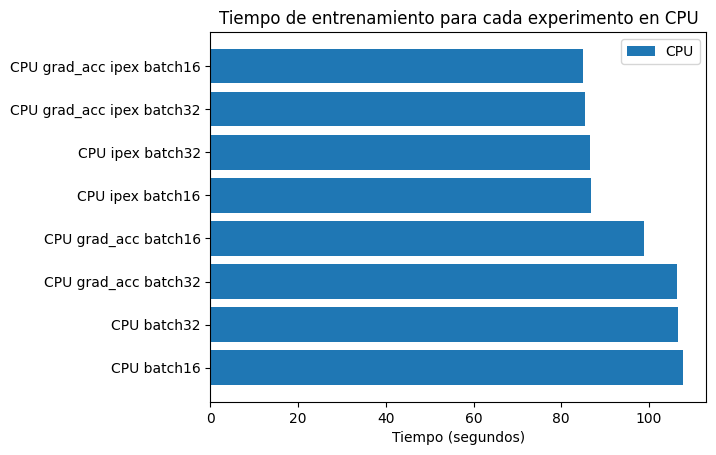

{'GPU batch16 fp16': 3.43, 'GPU grad_acc batch16 fp16': 4.8, 'GPU batch16 fp32': 4.79, 'GPU grad_acc batch16 fp32': 5.93, 'GPU batch32 fp16': 3.18, 'GPU grad_acc batch32 fp16': 4.06, 'GPU batch32 fp32': 4.13, 'GPU grad_acc batch32 fp32': 4.21}


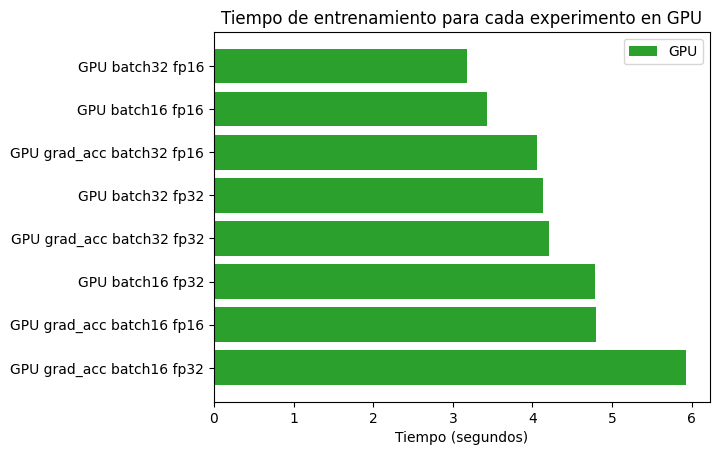

{'Multi-GPU batch16 fp16': 4.3, 'Multi-GPU grad_acc batch16 fp16': 4.38, 'Multi-GPU batch16 fp32': 2.89, 'Multi-GPU grad_acc batch16 fp32': 3.92, 'Multi-GPU batch32 fp16': 3.22, 'Multi-GPU grad_acc batch32 fp16': 4.2, 'Multi-GPU batch32 fp32': 3.51, 'Multi-GPU grad_acc batch32 fp32': 3.59}


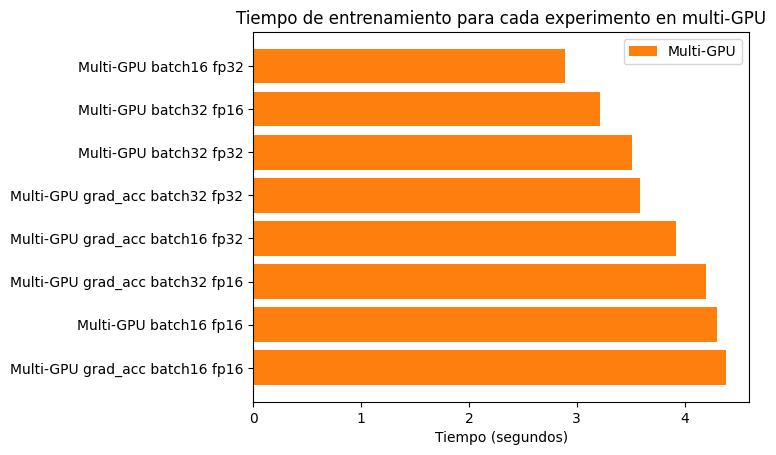

{'CPU batch16': 107.75, 'CPU grad_acc batch16': 98.82, 'CPU grad_acc ipex batch16': 85.0, 'CPU ipex batch16': 86.81, 'CPU batch32': 106.75, 'CPU grad_acc batch32': 106.44, 'CPU grad_acc ipex batch32': 85.43, 'CPU ipex batch32': 86.57, 'GPU batch16 fp16': 3.43, 'GPU grad_acc batch16 fp16': 4.8, 'GPU batch16 fp32': 4.79, 'GPU grad_acc batch16 fp32': 5.93, 'GPU batch32 fp16': 3.18, 'GPU grad_acc batch32 fp16': 4.06, 'GPU batch32 fp32': 4.13, 'GPU grad_acc batch32 fp32': 4.21, 'Multi-GPU batch16 fp16': 4.3, 'Multi-GPU grad_acc batch16 fp16': 4.38, 'Multi-GPU batch16 fp32': 2.89, 'Multi-GPU grad_acc batch16 fp32': 3.92, 'Multi-GPU batch32 fp16': 3.22, 'Multi-GPU grad_acc batch32 fp16': 4.2, 'Multi-GPU batch32 fp32': 3.51, 'Multi-GPU grad_acc batch32 fp32': 3.59}


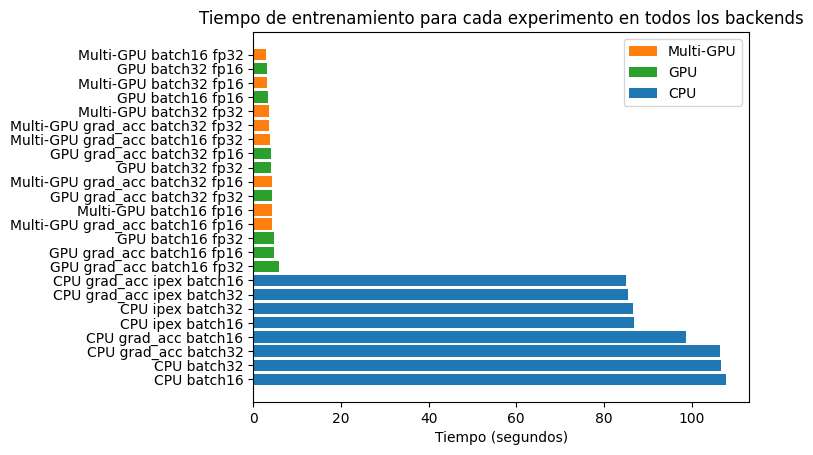

In [2]:
import matplotlib.pyplot as plt
import numpy as np

for iter_tuple in [("CPU",dict_cpu_time), ("GPU",dict_gpu_time), ("multi-GPU",dict_mgpu_time), ("todos los backends",dict_all_time)]:

    my_name = iter_tuple[0]
    my_dict = iter_tuple[1]

    fig, ax = plt.subplots()

    y_pos = np.arange(len(my_dict))

    print(my_dict)

    ordered_names = list(my_dict.keys())
    ordered_values = list(my_dict.values())

    ordered_names = sorted(ordered_names,key=my_dict.get)
    ordered_values = sorted(ordered_values)

    labels = ["CPU" if name.find("CPU") != -1 else "Multi-GPU" if name.find("Multi-GPU") != -1 else "GPU" for name in ordered_names]
    strings_that_appeared = set()
    for i in range(len(labels)):
        if labels[i] in strings_that_appeared:
            labels[i] = "_"+labels[i]
        else:
            strings_that_appeared.add(labels[i])
            
    colors = ["tab:blue" if name.find("CPU") != -1 else "tab:orange" if name.find("Multi-GPU") != -1 else "tab:green" for name in ordered_names]

    ax.barh(y_pos, ordered_values, align="center", color=colors, label=labels)
    ax.set_yticks(y_pos, labels=ordered_names)
    ax.invert_yaxis()
    ax.legend()
    ax.set_xlabel("Tiempo (segundos)")
    ax.set_title(f"Tiempo de entrenamiento para cada experimento en {my_name}")

    plt.show()

# Throughput

In [3]:
import os
import re

directory = os.fsencode("../logs")

dict_cpu_throughput = dict()
dict_gpu_throughput = dict()
dict_mgpu_throughput = dict()

throughput_pattern = re.compile(r"^Throughput: (\d+\.\d+) samples/s$")

throughput_pattern_cpu_gpu = re.compile(r"^Throughput: (\d+\.\d+) samples/s$")
throughput_pattern_mgpu = re.compile(r"^Throughput GLOBAL: (\d+\.\d+) samples/s$")

filename_patterns = ["grad_acc", "ipex", "batch16", "batch32", "fp16", "fp32"]

for file in os.listdir(directory):
    filename = os.fsdecode(file)
    if filename.endswith(".out"):
        for line in open(os.path.join(os.fsdecode(directory),filename)):
            if filename.find("_mgpu_") != -1:
                matches = re.findall(throughput_pattern_mgpu, line)
            else:
                matches = re.findall(throughput_pattern_cpu_gpu, line)

            if len(matches) != 1:
                continue
            
            match = matches[0]

            seconds = float(match)

            print(f"{filename}: {seconds} samples per second.")

            string_list = []

            for pattern in filename_patterns:
                if filename.find("_"+pattern+"_") != -1:
                    string_list.append(pattern)
            
            if filename.find("_cpu_") != -1:
                dict_cpu_throughput[" ".join(string_list)] = seconds
            elif filename.find("_gpu_") != -1:
                dict_gpu_throughput[" ".join(string_list)] = seconds
            elif filename.find("_mgpu_") != -1:
                dict_mgpu_throughput[" ".join(string_list)] = seconds
            else:
                print(f"ERROR: no se encontraron las subcadenas _cpu_, _gpu_ o _mgpu_ en el nombre del fichero {filename}")
                exit()

distilbert_job_train_cpu_batch16_2904.out: 2.38 samples per second.
distilbert_job_train_cpu_batch16_grad_acc_2903.out: 2.59 samples per second.
distilbert_job_train_cpu_batch16_grad_acc_ipex_2992.out: 3.01 samples per second.
distilbert_job_train_cpu_batch16_ipex_2997.out: 2.95 samples per second.
distilbert_job_train_cpu_batch32_2905.out: 2.4 samples per second.
distilbert_job_train_cpu_batch32_grad_acc_2906.out: 2.4 samples per second.
distilbert_job_train_cpu_batch32_grad_acc_ipex_2999.out: 2.99 samples per second.
distilbert_job_train_cpu_batch32_ipex_4502.out: 2.96 samples per second.
distilbert_job_train_gpu_batch16_fp16_2908.out: 74.55 samples per second.
distilbert_job_train_gpu_batch16_fp16_grad_acc_2907.out: 53.38 samples per second.
distilbert_job_train_gpu_batch16_fp32_2910.out: 53.45 samples per second.
distilbert_job_train_gpu_batch16_fp32_grad_acc_2909.out: 43.17 samples per second.
distilbert_job_train_gpu_batch32_fp16_2912.out: 80.45 samples per second.
distilbert_job

{'batch16': 2.38, 'grad_acc batch16': 2.59, 'grad_acc ipex batch16': 3.01, 'ipex batch16': 2.95, 'batch32': 2.4, 'grad_acc batch32': 2.4, 'grad_acc ipex batch32': 2.99, 'ipex batch32': 2.96}


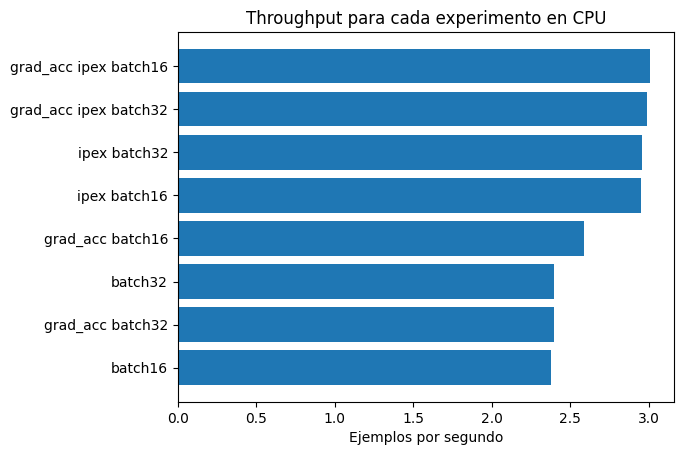

{'batch16 fp16': 74.55, 'grad_acc batch16 fp16': 53.38, 'batch16 fp32': 53.45, 'grad_acc batch16 fp32': 43.17, 'batch32 fp16': 80.45, 'grad_acc batch32 fp16': 63.05, 'batch32 fp32': 62.05, 'grad_acc batch32 fp32': 60.74}


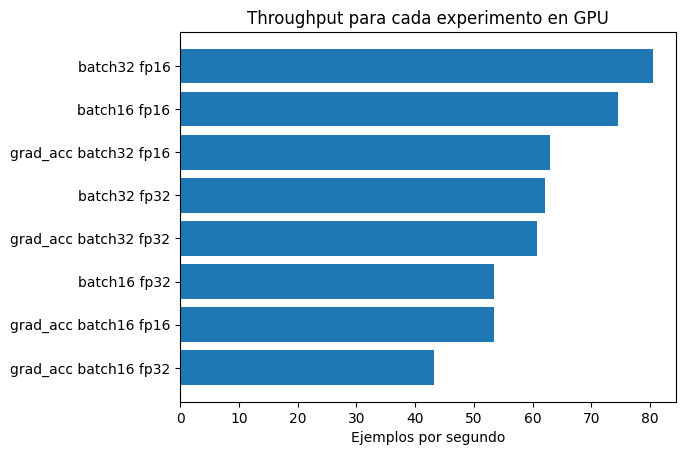

{'batch16 fp16': 59.56, 'grad_acc batch16 fp16': 58.49, 'batch16 fp32': 88.49, 'grad_acc batch16 fp32': 65.3, 'batch32 fp16': 79.43, 'grad_acc batch32 fp16': 60.99, 'batch32 fp32': 73.01, 'grad_acc batch32 fp32': 71.4}


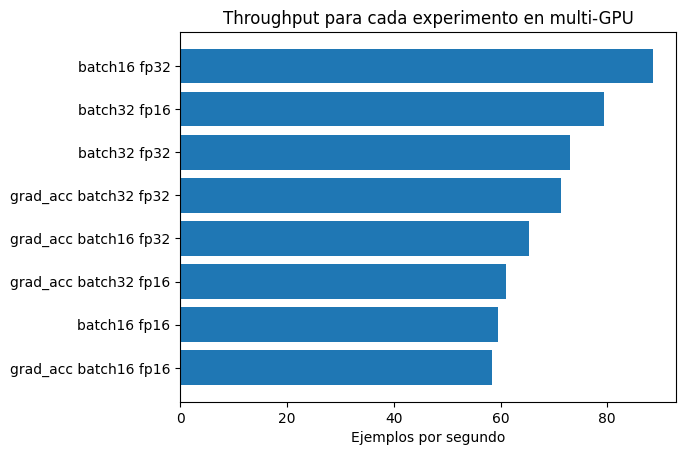

In [4]:
import matplotlib.pyplot as plt
import numpy as np

for iter_tuple in [("CPU",dict_cpu_throughput), ("GPU",dict_gpu_throughput), ("multi-GPU",dict_mgpu_throughput)]:

    my_name = iter_tuple[0]
    my_dict = iter_tuple[1]

    fig, ax = plt.subplots()

    y_pos = np.arange(len(my_dict))

    print(my_dict)

    ordered_names = list(my_dict.keys())
    ordered_values  =list(my_dict.values())

    ordered_names = sorted(ordered_names,key=my_dict.get, reverse=True)
    ordered_values = sorted(ordered_values, reverse=True)

    ax.barh(y_pos, ordered_values, align="center")
    ax.set_yticks(y_pos, labels=ordered_names)
    ax.invert_yaxis()
    ax.set_xlabel("Ejemplos por segundo")
    ax.set_title(f"Throughput para cada experimento en {my_name}")

    plt.show()

# Uso de memoria

In [5]:
import os

directory = os.fsencode("../results")

dict_cpu_ram = dict()
dict_gpu_ram = dict()
dict_mgpu_ram = dict()
dict_all_ram = dict()

filename_patterns = ["gradacc", "ipex", "batch16", "batch32", "fp16", "fp32"]

for file in os.listdir(directory):
    filename = os.fsdecode(file)
    if filename.startswith("memory"):
        max_ram_usage = 0
        max_vram_usage = 0
        for line in open(os.path.join(os.fsdecode(directory),filename)):
            data = line.split(",")

            if data[0] != "0":
                continue
                
            if float(data[2]) > max_ram_usage:
                max_ram_usage = float(data[2])
            if filename.find("_cpu_") == -1 and float(data[3]) > max_vram_usage:
                max_vram_usage = float(data[3])

        string_list = []

        if filename.find("_cpu_") != -1:
            string_list.append("CPU")
        elif filename.find("_gpu_") != -1:
            string_list.append("GPU")
        elif filename.find("_mgpu_") != -1:
            string_list.append("Multi-GPU")
        else:
            print(f"ERROR: no se encontraron las subcadenas _cpu_, _gpu_ o _mgpu_ en el nombre del fichero {filename}")
            exit()

        for pattern in filename_patterns:
            if filename.find(pattern) != -1:
                string_list.append(pattern)
        
        if filename.find("_cpu_") != -1:
            dict_cpu_ram[" ".join(string_list)] = (max_ram_usage,max_vram_usage)
        elif filename.find("_gpu_") != -1:
            dict_gpu_ram[" ".join(string_list)] = (max_ram_usage,max_vram_usage)
        elif filename.find("_mgpu_") != -1:
            dict_mgpu_ram[" ".join(string_list)] = (max_ram_usage,max_vram_usage)
        
        dict_all_ram[" ".join(string_list)] = (max_ram_usage,max_vram_usage)

{'CPU batch16': (2667.67578125, 0), 'CPU gradacc batch16': (2519.35546875, 0), 'CPU gradacc ipex batch16': (2863.49609375, 0), 'CPU ipex batch16': (2908.015625, 0), 'CPU batch32': (3788.5390625, 0), 'CPU gradacc batch32': (3716.984375, 0), 'CPU gradacc ipex batch32': (3948.80859375, 0), 'CPU ipex batch32': (4049.28125, 0)}


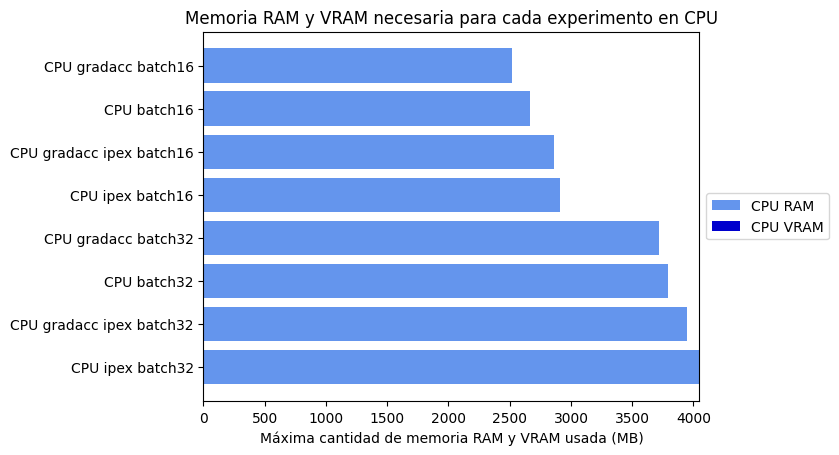

{'GPU batch16 fp16': (1210.10546875, 1056.24658203125), 'GPU gradacc batch16 fp16': (1206.71484375, 787.1279296875), 'GPU batch16 fp32': (1103.98046875, 1058.24560546875), 'GPU gradacc batch16 fp32': (1105.2890625, 788.751953125), 'GPU batch32 fp16': (1215.04296875, 1063.51220703125), 'GPU gradacc batch32 fp16': (1216.26953125, 791.7685546875), 'GPU batch32 fp32': (1090.23828125, 1046.76123046875), 'GPU gradacc batch32 fp32': (1091.54296875, 786.017578125)}


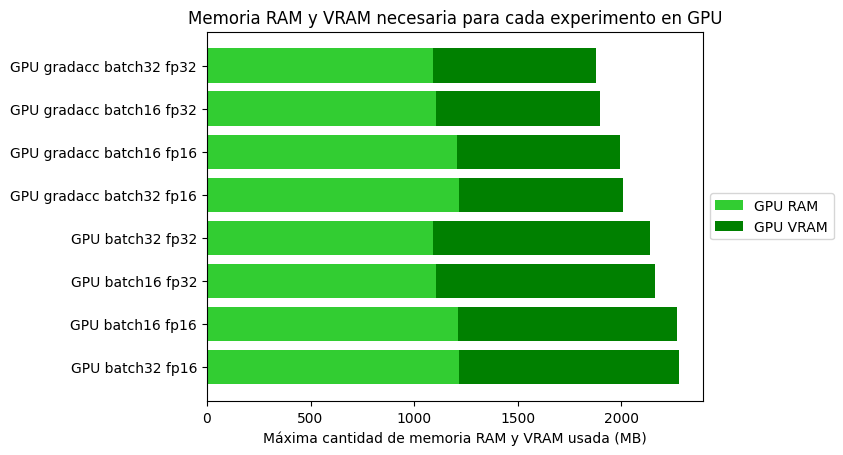

{'Multi-GPU batch16 fp16': (1570.78125, 1045.03564453125), 'Multi-GPU gradacc batch16 fp16': (1569.24609375, 1045.03564453125), 'Multi-GPU batch16 fp32': (1377.58984375, 1045.75244140625), 'Multi-GPU gradacc batch16 fp32': (1375.8203125, 1045.75244140625), 'Multi-GPU batch32 fp16': (1568.30859375, 1044.63134765625), 'Multi-GPU gradacc batch32 fp16': (1538.0703125, 1044.63134765625), 'Multi-GPU batch32 fp32': (1351.01171875, 1300.61669921875), 'Multi-GPU gradacc batch32 fp32': (1347.57421875, 1042.76806640625)}


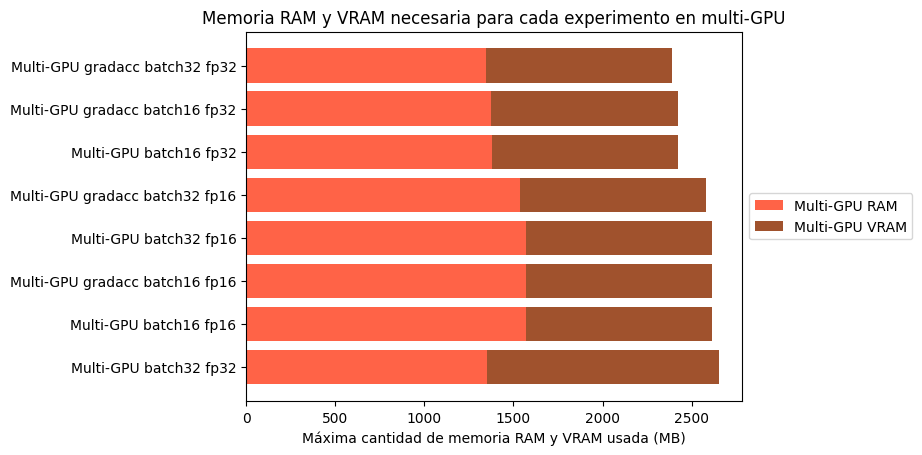

{'CPU batch16': (2667.67578125, 0), 'CPU gradacc batch16': (2519.35546875, 0), 'CPU gradacc ipex batch16': (2863.49609375, 0), 'CPU ipex batch16': (2908.015625, 0), 'CPU batch32': (3788.5390625, 0), 'CPU gradacc batch32': (3716.984375, 0), 'CPU gradacc ipex batch32': (3948.80859375, 0), 'CPU ipex batch32': (4049.28125, 0), 'GPU batch16 fp16': (1210.10546875, 1056.24658203125), 'GPU gradacc batch16 fp16': (1206.71484375, 787.1279296875), 'GPU batch16 fp32': (1103.98046875, 1058.24560546875), 'GPU gradacc batch16 fp32': (1105.2890625, 788.751953125), 'GPU batch32 fp16': (1215.04296875, 1063.51220703125), 'GPU gradacc batch32 fp16': (1216.26953125, 791.7685546875), 'GPU batch32 fp32': (1090.23828125, 1046.76123046875), 'GPU gradacc batch32 fp32': (1091.54296875, 786.017578125), 'Multi-GPU batch16 fp16': (1570.78125, 1045.03564453125), 'Multi-GPU gradacc batch16 fp16': (1569.24609375, 1045.03564453125), 'Multi-GPU batch16 fp32': (1377.58984375, 1045.75244140625), 'Multi-GPU gradacc batch16

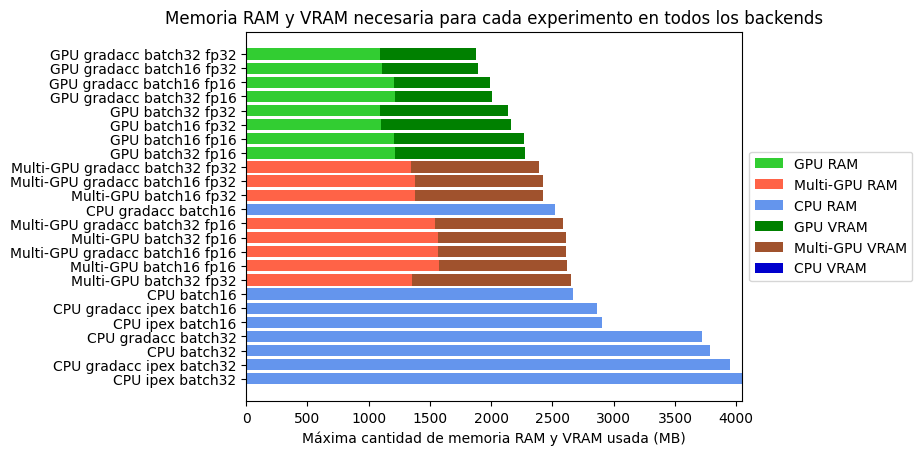

In [11]:
import matplotlib.pyplot as plt
import numpy as np

for iter_tuple in [("CPU",dict_cpu_ram), ("GPU",dict_gpu_ram), ("multi-GPU",dict_mgpu_ram), ("todos los backends",dict_all_ram)]:

    my_name = iter_tuple[0]
    my_dict = iter_tuple[1]

    fig, ax = plt.subplots()

    y_pos = np.arange(len(my_dict))

    print(my_dict)

    ordered_names = list(my_dict.keys())
    ordered_values  =list(my_dict.values())

    ordered_names = sorted(ordered_names,key=lambda key:my_dict[key][0]+my_dict[key][1])
    ordered_values = sorted(ordered_values,key=lambda value:value[0]+value[1])

    labels = ["CPU" if name.find("CPU") != -1 else "Multi-GPU" if name.find("Multi-GPU") != -1 else "GPU" for name in ordered_names]
    strings_that_appeared = set()
    for i in range(len(labels)):
        if labels[i] in strings_that_appeared:
            labels[i] = "_"+labels[i]
        else:
            strings_that_appeared.add(labels[i])

    colors_RAM = ["cornflowerblue" if name.find("CPU") != -1 else "tomato" if name.find("Multi-GPU") != -1 else "limegreen" for name in ordered_names]
    colors_VRAM = ["mediumblue" if name.find("CPU") != -1 else "sienna" if name.find("Multi-GPU") != -1 else "green" for name in ordered_names]

    ax.barh(y_pos, [ram for (ram,vram) in ordered_values], align="center", label=[label + " RAM" for label in labels], color=colors_RAM)
    ax.barh(y_pos, [vram for (ram,vram) in ordered_values], align="center", label=[label + " VRAM" for label in labels], color=colors_VRAM, left = [ram for (ram,vram) in ordered_values])
    ax.set_yticks(y_pos, labels=ordered_names)
    ax.invert_yaxis()
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    ax.set_xlabel("Máxima cantidad de memoria RAM y VRAM usada (MB)")
    ax.set_title(f"Memoria RAM y VRAM necesaria para cada experimento en {my_name}")

    plt.show()